## 1. Import and reading data

In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [9]:
db = sqlite3.connect("../data/checking-logs.sqlite")
df = pd.read_sql("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", db, parse_dates="timestamp")

## 2. Prerpocessing

In [10]:
df['hour'] = df['timestamp'].dt.hour
dow = df['timestamp'].dt.dayofweek
df['kind'] = 'working_day'
df.loc[dow >= 5, 'kind'] = 'weekend'

In [ ]:
hours_working = df.loc[df['kind'] == 'working_day', 'hour'].tolist()
hours_weekend = df.loc[df['kind'] == 'weekend', 'hour'].tolist()
len(hours_working)

[5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 11,
 11,
 14,
 14,
 14,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 17,
 17,
 17,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 18,
 18,
 18,
 18,
 18,
 18,
 19,
 19,
 20,
 20,
 20,
 20,
 20,
 20,
 22,
 22,
 12,
 13,
 13,
 13,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 20,
 21,
 21,
 21,
 22,
 22,
 22,
 22,
 22,
 22,
 0,
 0,
 7,
 7,
 8,
 8,
 8,
 8,
 11,
 11,
 12,
 12,
 12,
 12,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 14,
 14,
 20,
 20,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 10,
 10,
 16,
 16,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 22,
 22,
 3,
 3,
 8,
 8,
 21,
 21,
 11,
 11,
 11,
 11,
 16,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 22,
 22,
 22,
 22,
 22,
 22,
 5,
 5,
 7,
 7,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 11,
 15,
 15,
 15,
 15,
 18,

## 3. Creating graph

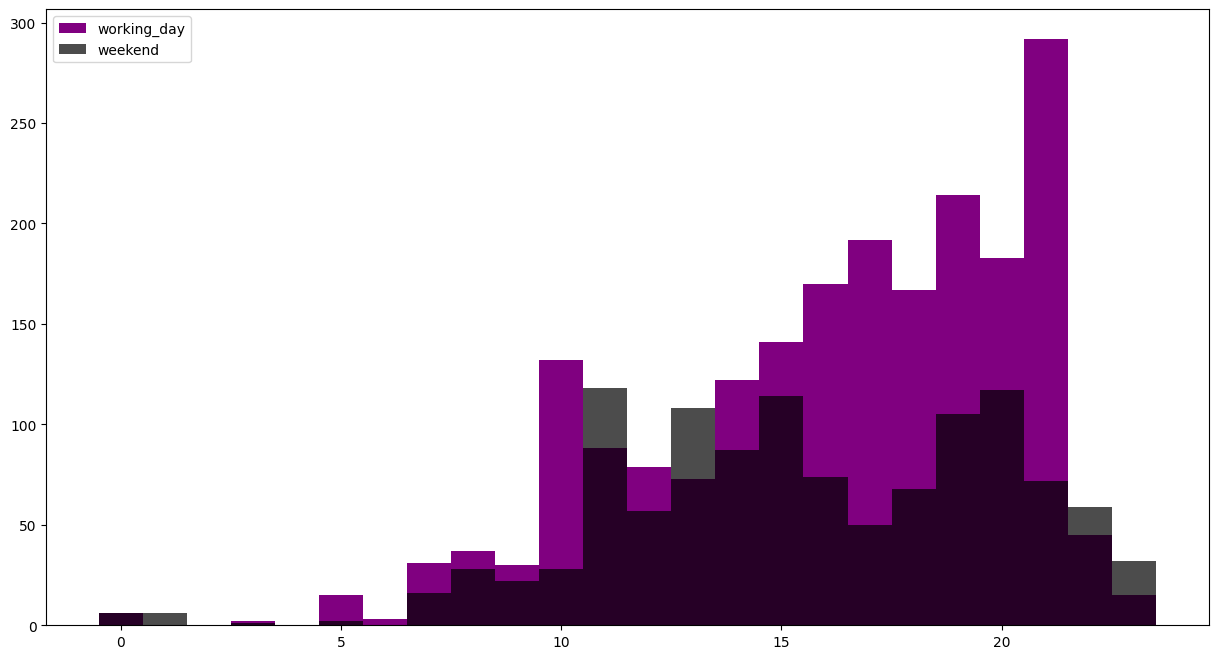

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(hours_working, bins=range(25), align='left', label='working_day', color="purple")
plt.hist(hours_weekend, bins=range(25), align='left', alpha=0.7, label='weekend', color='black')
plt.legend()
plt.show()

## 4. Questions
"Are there hours when the total number of commits was higher on weekends than on working days?"
### **Да**
- Там где чёрное(которое серое) вылезло выше - как раз такие дни. 11, 13, 23, 24 (еще 1й но просили топ4)

## 5. Close

In [ ]:
db.close()